In [36]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")


In [37]:
# Notebook lives in outputs/
PROJECT_ROOT = Path("..").resolve()


DQN_DIR = PROJECT_ROOT / "outputs" / "dqn"
PPO_DIR = PROJECT_ROOT / "outputs" / "ppo"


In [38]:
dqn_ep = pd.read_csv(DQN_DIR / "episode_log.csv")

dqn_ep.head()


,timesteps,episode_return,episode_length,action_0_count,action_1_count,action_2_count,action_0_share,action_1_share,action_2_share
0,256,-31672.8,256,78,91,87,0.304688,0.355469,0.339844
1,512,-31546.8,256,96,76,84,0.375000,0.296875,0.328125
2,768,-27088.8,256,79,82,95,0.308594,0.320312,0.371094
3,1024,-30162.0,256,89,87,80,0.347656,0.339844,0.312500
4,1280,-30884.4,256,74,88,94,0.289062,0.343750,0.367188


In [39]:
ppo_log = pd.read_csv(PPO_DIR / "train_log.csv")

ppo_log.head()


,timesteps,mean_step_reward,std_step_reward,min_step_reward,max_step_reward,action_0_count,action_1_count,action_2_count
0,16384,-115.778174,129.974055,-696.0,-0.0,5501,5469,5414
1,32768,-115.526514,130.607060,-696.0,-0.0,5375,5315,5694
2,49152,-114.531372,128.360573,-696.0,-0.0,5327,5437,5620
3,65536,-114.350830,128.744503,-696.0,-0.0,5355,5333,5696
4,81920,-113.248608,126.503477,-696.0,-0.0,5131,5405,5848


In [40]:
rows = []

# Baselines
for _, r in baseline_summary.iterrows():
    rows.append({
        "Method": r["baseline"],
        "Mean reward": r["mean"],
        "Std reward": r["std"]
    })

# DQN (episode-level)
rows.append({
    "Method": "DQN",
    "Mean reward": dqn_ep["episode_return"].mean(),
    "Std reward": dqn_ep["episode_return"].std()
})

# PPO (rollout-level proxy)
rows.append({
    "Method": "PPO",
    "Mean reward": ppo_log["mean_step_reward"].mean(),
    "Std reward": ppo_log["mean_step_reward"].std()
})

df_compare = pd.DataFrame(rows)
df_compare


,Method,Mean reward,Std reward
0,always_expedited,-24545.112000,1675.414799
1,always_normal,-34753.200000,2299.696755
2,always_priority,-29718.664000,2004.674742
3,DQN,-26085.476003,2100.732678
4,PPO,-113.404101,1.328881


In [41]:
order = [
    "always_normal",
    "always_priority",
    "always_expedited",
    "DQN",
    "PPO",
]

df_compare["Method"] = pd.Categorical(
    df_compare["Method"],
    categories=order,
    ordered=True
)

df_compare = df_compare.sort_values("Method")


In [42]:
dqn_actions = {
    "Normal": dqn_ep["action_0_count"].sum(),
    "Priority": dqn_ep["action_1_count"].sum(),
    "Expedited": dqn_ep["action_2_count"].sum(),
}

In [43]:
ppo_actions = pd.read_csv(PPO_DIR / "train_log.csv")[
    ["action_0_count", "action_1_count", "action_2_count"]
].sum()

ppo_actions = {
    "Normal": ppo_actions["action_0_count"],
    "Priority": ppo_actions["action_1_count"],
    "Expedited": ppo_actions["action_2_count"],
}


In [44]:
total_actions = sum(dqn_actions.values())

baseline_actions = {
    "Normal": 0,
    "Priority": 0,
    "Expedited": total_actions,
}

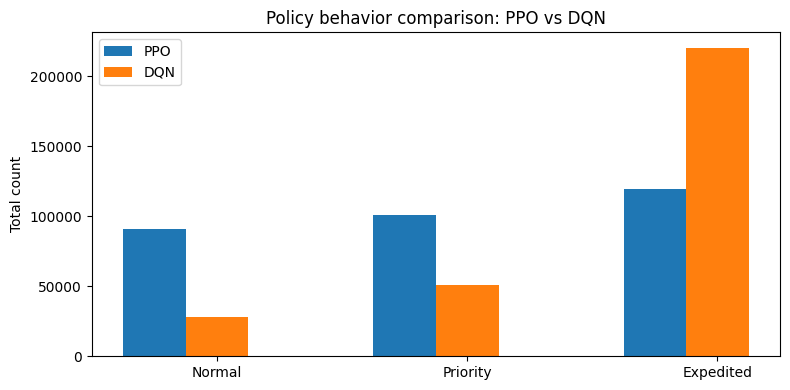

In [45]:
labels = ["Normal", "Priority", "Expedited"]
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8, 4))

plt.bar(
    x - width,
    [ppo_actions[l] for l in labels],
    width,
    label="PPO"
)

plt.bar(
    x,
    [dqn_actions[l] for l in labels],
    width,
    label="DQN"
)



plt.xticks(x, labels)
plt.ylabel("Total count")
plt.title("Policy behavior comparison: PPO vs DQN")
plt.legend()
plt.tight_layout()
plt.show()



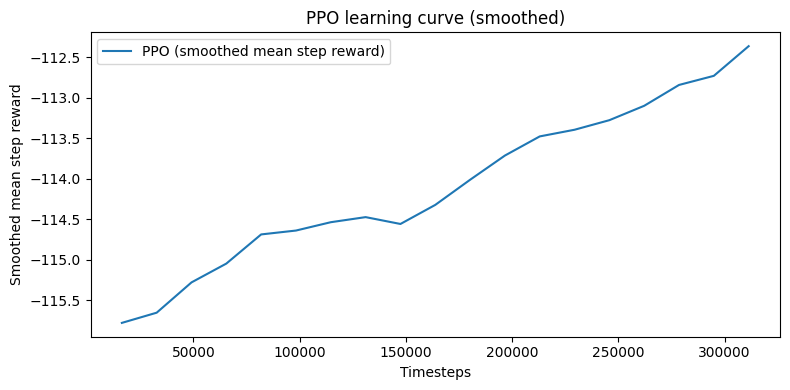

In [66]:
# PPO smoothed learning curve
ppo_log = ppo_log.sort_values("timesteps").copy()

ppo_log["reward_smooth"] = (
    ppo_log["mean_step_reward"]
    .rolling(window=10, min_periods=1)
    .mean()
)

plt.figure(figsize=(8, 4))
plt.plot(
    ppo_log["timesteps"],
    ppo_log["reward_smooth"],
    label="PPO (smoothed mean step reward)"
)

plt.xlabel("Timesteps")
plt.ylabel("Smoothed mean step reward")
plt.title("PPO learning curve (smoothed)")
plt.legend()
plt.tight_layout()
plt.show()


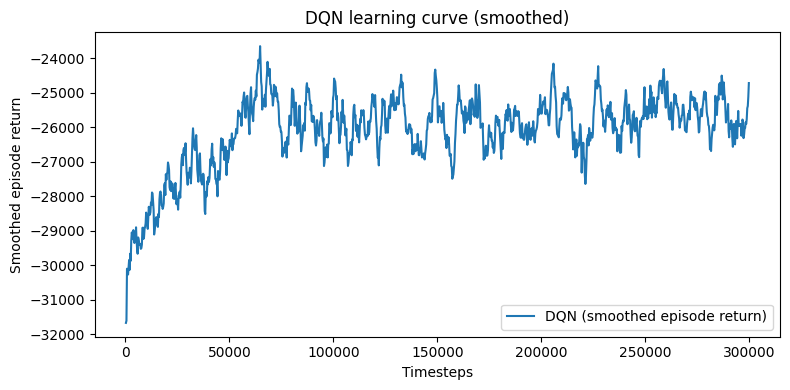

In [67]:
# DQN smoothed learning curve
dqn_ep = dqn_ep.sort_values("timesteps").copy()

dqn_ep["reward_smooth"] = (
    dqn_ep["episode_return"]
    .rolling(window=10, min_periods=1)
    .mean()
)

plt.figure(figsize=(8, 4))
plt.plot(
    dqn_ep["timesteps"],
    dqn_ep["reward_smooth"],
    label="DQN (smoothed episode return)"
)

plt.xlabel("Timesteps")
plt.ylabel("Smoothed episode return")
plt.title("DQN learning curve (smoothed)")
plt.legend()
plt.tight_layout()
plt.show()


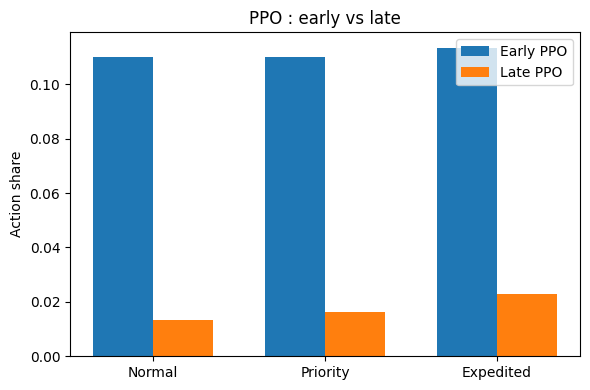

In [82]:
# --- PPO early vs late snapshot ---
ppo_actions = ppo_log[
    ["action_0_count", "action_1_count", "action_2_count"]
].copy()

ppo_actions["timesteps"] = ppo_log["timesteps"]

split = int(len(ppo_actions) * 0.2)

ppo_early = ppo_actions.iloc[:split].sum()
ppo_late  = ppo_actions.iloc[-split:].sum()

ppo_early = ppo_early / ppo_early.sum()
ppo_late  = ppo_late / ppo_late.sum()

labels = ["Normal", "Priority", "Expedited"]
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6, 4))
plt.bar(x - width/2, ppo_early[:3], width, label="Early PPO")
plt.bar(x + width/2, ppo_late[:3], width, label="Late PPO")

plt.xticks(x, labels)
plt.ylabel("Action share")
plt.title("PPO : early vs late")
plt.legend()
plt.tight_layout()
plt.show()


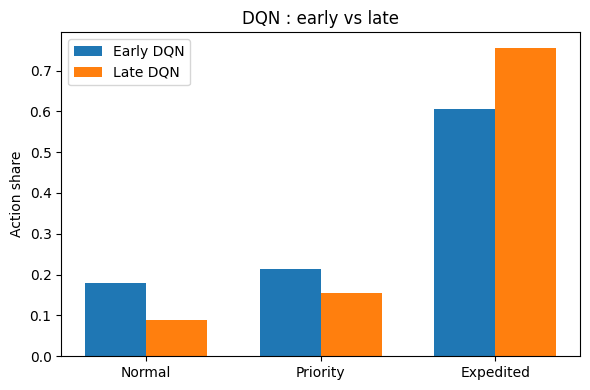

In [81]:
# --- DQN early vs late snapshot ---
dqn_actions = dqn_ep[
    ["action_0_share", "action_1_share", "action_2_share"]
].copy()

split = int(len(dqn_actions) * 0.2)

dqn_early = dqn_actions.iloc[:split].mean()
dqn_late  = dqn_actions.iloc[-split:].mean()

plt.figure(figsize=(6, 4))
plt.bar(x - width/2, dqn_early, width, label="Early DQN")
plt.bar(x + width/2, dqn_late, width, label="Late DQN")

plt.xticks(x, labels)
plt.ylabel("Action share")
plt.title("DQN : early vs late")
plt.legend()
plt.tight_layout()
plt.show()


In [78]:
dqn_ep["determinism"] = dqn_ep[
    ["action_0_share", "action_1_share", "action_2_share"]
].max(axis=1)

dqn_ep["determinism_smooth"] = (
    dqn_ep["determinism"]
    .rolling(10, min_periods=1)
    .mean()
)


In [79]:
ppo_counts = ppo_log[
    ["action_0_count", "action_1_count", "action_2_count"]
].copy()

ppo_totals = ppo_counts.sum(axis=1).replace(0, np.nan)
ppo_shares = ppo_counts.div(ppo_totals, axis=0)

ppo_log["determinism"] = ppo_shares.max(axis=1)

ppo_log["determinism_smooth"] = (
    ppo_log["determinism"]
    .rolling(10, min_periods=1)
    .mean()
)


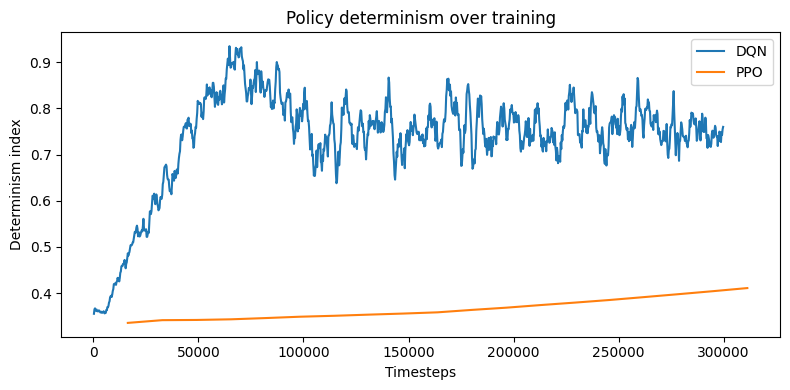

In [80]:
plt.figure(figsize=(8, 4))
plt.plot(dqn_ep["timesteps"], dqn_ep["determinism_smooth"], label="DQN")
plt.plot(ppo_log["timesteps"], ppo_log["determinism_smooth"], label="PPO")

plt.xlabel("Timesteps")
plt.ylabel("Determinism index")
plt.title("Policy determinism over training")
plt.legend()
plt.tight_layout()
plt.show()
